# 04 - Nowcasting Validation

Purpose:
- bridge the gap between descriptive evidence and operational alarm construction;
- test whether Gold looks more useful as a current-state instability indicator than as a return-forecasting signal;
- compare a preliminary Gold abnormality score against simple stress proxies and known regime windows;
- decide whether it is reasonable to proceed to the grouped Gold alarm in the next notebook.

Framing:
This notebook does not prove a final dashboard rule. It validates the direction of travel: if direct forecasting is weak, does Gold still help nowcast unstable cross-market conditions?

## Reader Orientation

Notebook 03 showed that direct return-level lead-lag evidence is not strong enough to frame the project as forecasting. This notebook asks the next logical question: even if Gold is not a clean predictor, does abnormal Gold behaviour align with current periods of market stress closely enough to justify an escalation dashboard?

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "step04_nowcasting"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
market_vars_path = PROCESSED_DIR / "market_vars_core.parquet"
if not market_vars_path.exists():
    market_vars_path = PROCESSED_DIR / "market_vars.parquet"

prices_path = PROCESSED_DIR / "prices_clean_core.parquet"
if not prices_path.exists():
    prices_path = PROCESSED_DIR / "prices_clean.parquet"

market_vars = pd.read_parquet(market_vars_path)
prices = pd.read_parquet(prices_path)

CORE_COLUMNS = ["r_Gold", "r_Brent", "r_DXY", "d_VIX", "d_US10Y"]
missing_cols = [col for col in CORE_COLUMNS if col not in market_vars.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns from Step 02 output: {missing_cols}")

market_vars = market_vars[CORE_COLUMNS].dropna().copy()
prices = prices.reindex(market_vars.index)

print("Market vars:", market_vars_path, market_vars.shape)
print("Prices:", prices_path, prices.shape)
market_vars.tail()


Market vars: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\market_vars_core.parquet (4685, 5)
Prices: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\data\processed\prices_clean_core.parquet (4685, 5)


Ticker,r_Gold,r_Brent,r_DXY,d_VIX,d_US10Y
Date,,,,,
2026-05-29,0.013510,-0.017873,-0.001111,-0.420000,-0.002
2026-06-01,-0.018881,0.031334,0.002928,0.730000,0.022
2026-06-02,0.003101,0.010682,0.000202,-0.279999,-0.020
2026-06-03,-0.011741,0.018679,0.003119,0.289999,0.036
2026-06-04,0.008774,-0.028834,-0.001206,-0.660000,-0.014


## Helper Functions

All abnormality measures use shifted trailing baselines. This keeps the validation aligned with a real dashboard setting, where today's alert cannot use today's value to define today's normal regime.

## Parameter Rationale

These defaults are deliberately interpretable rather than optimized:

- `BASELINE_WIN = 252`: roughly one trading year, used to define a trailing normal regime.
- `CORR_WIN = 60`: roughly one trading quarter, used to detect relationship shifts without reacting to every short-term move.
- `VOL_WIN = 30`: roughly one trading month, used for short-term realized volatility.
- `STRESS_PROXY_THRESHOLD = 2.0`: a stricter z-score cutoff for defining simple stress proxies.
- `GOLD_SCORE_THRESHOLD = 1.5`: a more sensitive cutoff because this stage is exploratory and asks whether Gold abnormality appears near stress windows.
- `NOWCAST_WINDOWS = [5, 10, 20]`: one week, two weeks, and one month. This checks whether Gold is a sharp near-term signal or a broader review-window signal.


In [3]:
BASELINE_WIN = 252
CORR_WIN = 60
VOL_WIN = 30
STRESS_PROXY_THRESHOLD = 2.0
GOLD_SCORE_THRESHOLD = 1.5
NOWCAST_WINDOWS = [5, 10, 20]

CONDITIONING_COLS = ["r_Brent", "r_DXY", "d_VIX", "d_US10Y"]


def trailing_zscore(series: pd.Series, window: int = BASELINE_WIN) -> pd.Series:
    mean = series.rolling(window).mean().shift(1)
    std = series.rolling(window).std().shift(1)
    return (series - mean) / std


def event_starts(flag: pd.Series) -> pd.DatetimeIndex:
    flag = flag.fillna(0).astype(int)
    starts = flag.eq(1) & flag.shift(1, fill_value=0).eq(0)
    return pd.DatetimeIndex(flag.index[starts])


def window_hit_rate(signal_dates: pd.DatetimeIndex, event_dates: pd.DatetimeIndex, window_days: int) -> dict:
    rows = []
    for event_date in event_dates:
        hits = signal_dates[
            (signal_dates >= event_date - pd.Timedelta(days=window_days))
            & (signal_dates <= event_date + pd.Timedelta(days=window_days))
        ]
        rows.append({
            "event_date": event_date,
            "matched": len(hits) > 0,
            "nearest_signal_date": hits[0] if len(hits) else pd.NaT,
        })
    table = pd.DataFrame(rows)
    return {
        "event_count": len(table),
        "matched_count": int(table["matched"].sum()) if len(table) else 0,
        "match_rate": float(table["matched"].mean()) if len(table) else np.nan,
    }


## Build A Preliminary Gold Nowcasting Score

This is intentionally simpler than the final operating alarm. It uses three ideas from the earlier evidence:

1. Gold's own return can become abnormal.
2. Gold volatility can become abnormal.
3. Gold's relationships with Brent, DXY, VIX, and US10Y can become abnormal.

If this simple score has no relationship to unstable periods, there is little reason to build a more formal alarm.

In [4]:
components = pd.DataFrame(index=market_vars.index)
components["gold_return_z"] = trailing_zscore(market_vars["r_Gold"])
components["gold_vol_z"] = trailing_zscore(market_vars["r_Gold"].rolling(VOL_WIN).std())

for col in CONDITIONING_COLS:
    rolling_corr = market_vars["r_Gold"].rolling(CORR_WIN).corr(market_vars[col])
    components[f"gold_corr_{col}_z"] = trailing_zscore(rolling_corr)

corr_cols = [col for col in components.columns if col.startswith("gold_corr_")]
components["gold_relationship_score"] = components[corr_cols].abs().mean(axis=1)
components["gold_nowcast_score"] = components[["gold_return_z", "gold_vol_z", "gold_relationship_score"]].abs().mean(axis=1)
components["gold_nowcast_alarm"] = (components["gold_nowcast_score"] > GOLD_SCORE_THRESHOLD).astype(int)

components.tail()


,gold_return_z,gold_vol_z,gold_corr_r_Brent_z,gold_corr_r_DXY_z,gold_corr_d_VIX_z,gold_corr_d_US10Y_z,gold_relationship_score,gold_nowcast_score,gold_nowcast_alarm
Date,,,,,,,,,
2026-05-29,0.721627,-0.497187,-2.697582,0.977353,-1.116283,-2.385849,1.794267,1.004360,0
2026-06-01,-1.184356,-0.496243,-2.660083,0.957864,-1.097505,-2.336282,1.762934,1.147844,0
2026-06-02,0.112020,-0.498998,-2.858296,1.021930,-1.513160,-2.296221,1.922402,0.844473,0
2026-06-03,-0.760371,-0.563094,-2.796703,0.999715,-1.680233,-2.296737,1.943347,1.088937,0
2026-06-04,0.451425,-0.552772,-2.534943,1.098227,-1.676981,-2.335865,1.911504,0.971900,0


### Interpretation

This score is not yet the dashboard rule. It is a validation device. If Gold abnormality is meaningful for nowcasting, the score should be elevated around unstable market conditions, even if it does not forecast returns several days ahead.

## Build Simple Contemporaneous Stress Proxies

Before the VaR notebook exists, we can use simple current-state stress proxies:

- Brent realized-volatility spike;
- VIX level spike;
- large Brent return shock.

These are intentionally simple baselines. They help answer whether Gold adds a cross-market instability view rather than just duplicating obvious Brent or VIX stress.

In [5]:
stress = pd.DataFrame(index=market_vars.index)

brent_vol = market_vars["r_Brent"].rolling(VOL_WIN).std()
stress["brent_vol_z"] = trailing_zscore(brent_vol)
stress["brent_return_abs_z"] = trailing_zscore(market_vars["r_Brent"]).abs()

if "VIX" in prices.columns:
    stress["vix_level_z"] = trailing_zscore(prices["VIX"])
else:
    stress["vix_level_z"] = np.nan

stress["brent_vol_spike"] = (stress["brent_vol_z"] > STRESS_PROXY_THRESHOLD).astype(int)
stress["brent_return_shock"] = (stress["brent_return_abs_z"] > STRESS_PROXY_THRESHOLD).astype(int)
stress["vix_level_spike"] = (stress["vix_level_z"] > STRESS_PROXY_THRESHOLD).astype(int)
stress["any_stress_proxy"] = stress[["brent_vol_spike", "brent_return_shock", "vix_level_spike"]].max(axis=1)

stress.tail()


,brent_vol_z,brent_return_abs_z,vix_level_z,brent_vol_spike,brent_return_shock,vix_level_spike,any_stress_proxy
Date,,,,,,,
2026-05-29,0.958786,0.619920,-0.864775,0,0,0,0
2026-06-01,0.726394,0.957437,-0.636338,0,0,0,0
2026-06-02,0.635840,0.291287,-0.717483,0,0,0,0
2026-06-03,0.612158,0.544668,-0.625127,0,0,0,0
2026-06-04,0.591628,0.972492,-0.822612,0,0,0,0


## Nowcasting Window Hit Test

For nowcasting, the key question is not only whether Gold fires before the event. It is whether Gold abnormality appears near the same unstable market window. We therefore test symmetric windows around stress-proxy event starts.

In [6]:
gold_alarm_dates = event_starts(components["gold_nowcast_alarm"])
proxy_events = {
    "brent_vol_spike": event_starts(stress["brent_vol_spike"]),
    "brent_return_shock": event_starts(stress["brent_return_shock"]),
    "vix_level_spike": event_starts(stress["vix_level_spike"]),
    "any_stress_proxy": event_starts(stress["any_stress_proxy"]),
}

window_rows = []
for event_family, event_dates in proxy_events.items():
    for window in NOWCAST_WINDOWS:
        result = window_hit_rate(gold_alarm_dates, event_dates, window)
        result["event_family"] = event_family
        result["window_days"] = window
        window_rows.append(result)

nowcasting_window_summary = pd.DataFrame(window_rows)[[
    "event_family", "window_days", "event_count", "matched_count", "match_rate"
]]
nowcasting_window_summary


,event_family,window_days,event_count,matched_count,match_rate
0,brent_vol_spike,5,21,5,0.238095
1,brent_vol_spike,10,21,9,0.428571
2,brent_vol_spike,20,21,13,0.619048
3,brent_return_shock,5,229,64,0.279476
4,brent_return_shock,10,229,93,0.406114
5,brent_return_shock,20,229,143,0.624454
6,vix_level_spike,5,55,18,0.327273
7,vix_level_spike,10,55,28,0.509091
8,vix_level_spike,20,55,32,0.581818
9,any_stress_proxy,5,175,44,0.251429


### How To Read This Table

A high match rate means Gold abnormality is present near current stress-proxy events. This supports nowcasting. A low match rate means Gold may be missing important stress regimes or the threshold is poorly calibrated. This is not a forecasting test; it is a current-regime alignment test.

## Known Event Window Check

Known stress windows are useful for interpretation, not proof. They help the reader see whether the score behaves sensibly during named market regimes.

In [7]:
EVENT_WINDOWS = [
    ("2011-08-01", "2011-10-01", "US debt downgrade / gold stress"),
    ("2013-04-01", "2013-07-01", "Gold crash / taper concerns"),
    ("2020-02-15", "2020-05-15", "COVID + oil war"),
    ("2022-02-15", "2022-04-15", "Russia/Ukraine shock"),
    ("2025-04-01", "2025-05-15", "Tariff shock"),
    ("2026-02-25", "2026-05-31", "Recent geopolitical stress"),
]

normal_score = components["gold_nowcast_score"].dropna()
normal_mean = normal_score.mean()
normal_p95 = normal_score.quantile(0.95)

event_rows = []
for start, end, label in EVENT_WINDOWS:
    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)
    window_score = components.loc[start_ts:end_ts, "gold_nowcast_score"].dropna()
    window_alarm = components.loc[start_ts:end_ts, "gold_nowcast_alarm"].dropna()
    event_rows.append({
        "event": label,
        "start": start,
        "end": end,
        "obs": len(window_score),
        "score_mean": window_score.mean() if len(window_score) else np.nan,
        "score_max": window_score.max() if len(window_score) else np.nan,
        "normal_mean": normal_mean,
        "normal_p95": normal_p95,
        "alarm_days": int(window_alarm.sum()) if len(window_alarm) else 0,
        "alarm_rate": float(window_alarm.mean()) if len(window_alarm) else np.nan,
    })

event_window_summary = pd.DataFrame(event_rows)
event_window_summary


,event,start,end,obs,score_mean,score_max,normal_mean,normal_p95,alarm_days,alarm_rate
0,US debt downgrade / gold stress,2011-08-01,2011-10-01,41,2.006213,4.027519,0.921823,1.836078,34,0.829268
1,Gold crash / taper concerns,2013-04-01,2013-07-01,64,1.379975,5.149336,0.921823,1.836078,27,0.421875
2,COVID + oil war,2020-02-15,2020-05-15,63,2.092389,4.518615,0.921823,1.836078,42,0.666667
3,Russia/Ukraine shock,2022-02-15,2022-04-15,42,1.680065,2.991725,0.921823,1.836078,28,0.666667
4,Tariff shock,2025-04-01,2025-05-15,32,1.933985,2.909269,0.921823,1.836078,25,0.781250
5,Recent geopolitical stress,2026-02-25,2026-05-31,66,0.947327,1.875556,0.921823,1.836078,2,0.030303


## Baseline Comparison

A Gold nowcasting score is only useful if it adds a perspective beyond simple Brent or VIX stress. This section compares alarm overlap and standalone firing rates.

In [8]:
baseline = pd.DataFrame(index=market_vars.index)
baseline["gold_nowcast_alarm"] = components["gold_nowcast_alarm"]
baseline["brent_vol_alarm"] = stress["brent_vol_spike"]
baseline["vix_level_alarm"] = stress["vix_level_spike"]
baseline["stress_proxy"] = stress["any_stress_proxy"]

baseline_summary = pd.DataFrame([
    {
        "signal": col,
        "active_days": int(baseline[col].sum()),
        "active_rate": float(baseline[col].mean()),
        "overlap_with_stress_proxy": float((baseline[col].eq(1) & baseline["stress_proxy"].eq(1)).sum() / max(baseline[col].sum(), 1)),
    }
    for col in ["gold_nowcast_alarm", "brent_vol_alarm", "vix_level_alarm"]
])

baseline_summary


,signal,active_days,active_rate,overlap_with_stress_proxy
0,gold_nowcast_alarm,403,0.086019,0.498759
1,brent_vol_alarm,428,0.091355,1.000000
2,vix_level_alarm,301,0.064248,1.000000


## Visual Check

The plot below shows whether the preliminary Gold score rises near the same periods as simple Brent/VIX stress proxies. It is meant for diagnostic interpretation, not formal proof.

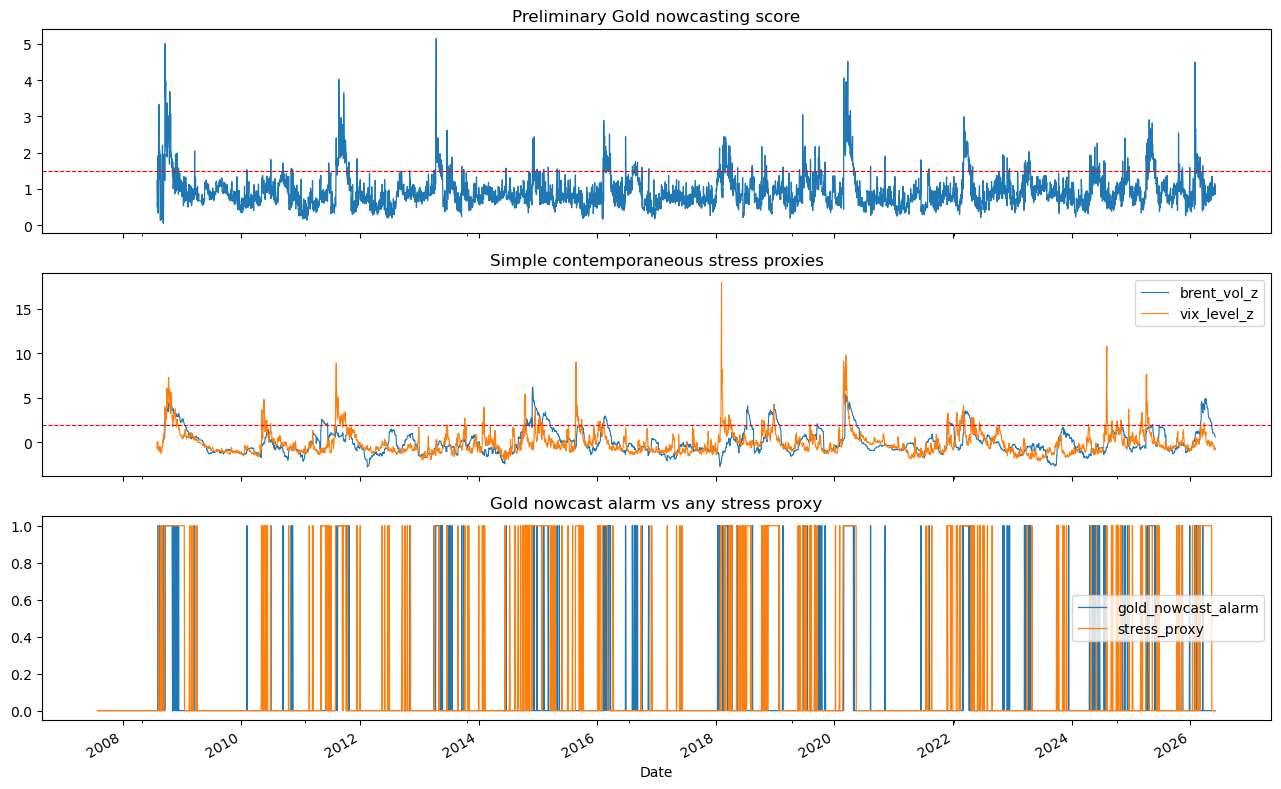

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

components["gold_nowcast_score"].plot(ax=axes[0], linewidth=0.9)
axes[0].axhline(GOLD_SCORE_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[0].set_title("Preliminary Gold nowcasting score")

stress[["brent_vol_z", "vix_level_z"]].plot(ax=axes[1], linewidth=0.8)
axes[1].axhline(STRESS_PROXY_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[1].set_title("Simple contemporaneous stress proxies")

baseline[["gold_nowcast_alarm", "stress_proxy"]].plot(ax=axes[2], linewidth=0.9)
axes[2].set_title("Gold nowcast alarm vs any stress proxy")

plt.tight_layout()


## Step 04 Working Takeaways

This notebook is the decision bridge:

- If direct lead-lag is weak, forecasting is not the right framing.
- If Gold abnormality aligns with current stress windows, nowcasting is a defensible framing.
- If Gold alignment is imperfect but non-trivial, the dashboard should be framed as an escalation tool rather than an automatic loss-warning system.
- The next notebook can build the formal grouped Gold alarm, but its limitation should remain clear: the alarm is conditional on the chosen market universe.

In [10]:
components.to_parquet(PROCESSED_DIR / "gold_nowcasting_validation_components.parquet")
stress.to_parquet(PROCESSED_DIR / "nowcasting_stress_proxies.parquet")
nowcasting_window_summary.to_csv(OUTPUT_DIR / "nowcasting_window_summary.csv", index=False)
event_window_summary.to_csv(OUTPUT_DIR / "event_window_nowcasting_summary.csv", index=False)
baseline_summary.to_csv(OUTPUT_DIR / "baseline_nowcasting_comparison.csv", index=False)

print("Saved Step 04 nowcasting validation outputs to:", OUTPUT_DIR)


Saved Step 04 nowcasting validation outputs to: C:\Users\sohwe\Desktop\SMU\MQF\Commodities Risk Management\qf637\outputs\step04_nowcasting
